# Multitask ConvNeXt + StarDist — GS40 Training Setup

One forward pass → **nuclear segmentation** + **per-nucleus tissue classification**.

## Quick start
1. Edit **Cell 2 — PARAMETERS**. Nothing else needs changing for a new run.
2. Run cells top-to-bottom for a full dataset-build + training run.
3. **Fine-tune only:** run Cells 1–2, then jump to Cell 10 (write config) → Cell 11 (run).

## Helper functions
All logic lives in `train_utils.py` (same folder).  
Open it to read or modify any function — each has a docstring explaining what it does.

| Cell | What it does | Key function |
|------|------|--------------|
| 2 | **PARAMETERS** — only cell to edit | — |
| 3 | Load train/val stems | `read_stems` |
| 4 | Rasterize JSON → instance mask PNG | `rasterize_masks` |
| 5 | Build `inst2class` sidecars (KD-tree) | `build_all_inst2class` |
| 6 | Diagnostics: match rate + class distribution | `diagnose_match_quality`, `diagnose_class_distribution` |
| 7 | Audit, failsafe, filter valid stems | `audit_stems`, `filter_stems` |
| 8 | Visualise samples + centroid overlay | `visualise_samples`, `diagnostic_centroid_viz` |
| 9 | Export QuPath validation GeoJSONs | `export_qupath_geojsons` |
| 10 | Write training config YAML | `build_training_config`, `write_config` |
| 11 | Run training / fine-tune | `run_training` |

In [3]:
# ── Imports ───────────────────────────────────────────────────────────────────
# Run once.  All helper functions come from train_utils.py — open it to
# read or edit any function without cluttering this notebook.
import random
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt

from train_utils import *
print('Imports OK — helper functions loaded from train_utils.py')

Imports OK — helper functions loaded from train_utils.py


---
## Cell 2 — PARAMETERS  ← edit here
This is the **only cell you need to change** for a new experiment or fine-tune run.

In [ ]:
# ── Data paths ───────────────────────────────────────────────────────────────
DATASET_ROOT      = Path(r"\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_256_40k_48_slides")
TRAIN_IMAGES_DIR  = DATASET_ROOT / "train" / "images"
TRAIN_CSV_DIR     = DATASET_ROOT / "train" / "labels"   # CellViT CSVs  (x, y, class_id)
VAL_CSV_DIR       = DATASET_ROOT / "val"   / "labels"
STARDIST_JSON_DIR = TRAIN_IMAGES_DIR / "StarDist_4_3_2026_cross_fetal_species" / "json"
MT_READY_DIR      = DATASET_ROOT / "stardist_multitask_ready"
INST_LABELS_DIR   = MT_READY_DIR / "train_instance_labels"  # masks + inst2class JSONs
SPLITS_DIR        = MT_READY_DIR / "splits"

# ── Output paths ─────────────────────────────────────────────────────────────
CKPT_OUT    = DATASET_ROOT / "convnext_stardist_multitask_runs" / "run_fold0_FULL"
CONFIG_PATH = Path(r"C:\Users\Andre\cursor_projects\Convnext_stardist\shared_convnext_stardist_decoder\config_gs40_multitask.yaml")
REPO_ROOT   = Path(r"C:\Users\Andre\cursor_projects\Convnext_stardist")

# ── Class names — channel i of the model output = tissue i ───────────────────
# Keep this order fixed.  Changing it requires rebuilding inst2class (Cell 5).
CLASS_NAMES = [
    "bone",       # 0
    "brain",      # 1
    "eye",        # 2
    "heart",      # 3
    "lungs",      # 4
    "gi",         # 5
    "liver",      # 6
    "spleen",     # 7
    "pancreas",   # 8
    "kidney",     # 9
    "mesokidney", # 10
    "collagen",   # 11
    "ear",        # 12
    "nontissue",  # 13
    "thymus",     # 14
    "thyroid",    # 15
    "bladder",    # 16
    "skull",      # 17
    "spleen2",    # 18
]

# ── Display colours (same index order as CLASS_NAMES) ────────────────────────
COLORS_VIZ = [
    [214,212,161], [247,184, 67], [136,232, 95], [140, 13, 13], [ 38, 27,166],
    [ 13,125, 11], [179, 50,108], [228,235,131], [156, 96,235], [ 46,190,230],
    [150,255,245], [254,222,255], [235,154,108], [255,255,255], [  9, 64,116],
    [255,255, 74], [178,178,  0], [214,212,161], [ 54, 83, 89],
]

# ── inst2class building ──────────────────────────────────────────────────────
FORCE_REBUILD_INST2CLASS = True   # True = overwrite all  |  False = only missing
MAX_MATCH_DIST_PX        = 12     # max px gap between CellViT and StarDist centroid

# ── Visualisation ────────────────────────────────────────────────────────────
N_VISUALISE     = 4     # random tiles shown in Cell 8
N_CENTROID_DIAG = 2     # tiles for centroid overlay diagnostic
EXPORT_EVERY_N  = 500   # QuPath: 1 tile every N  (set 1 for all)

# ── Training hyperparameters ─────────────────────────────────────────────────
EPOCHS                 = 35      # reduced (early stopping will likely trigger earlier)
BATCH_SIZE             = 8       # increased if VRAM allows (better gradient estimates)
LR                     = 5e-5    # reduced from 1e-4 (less aggressive after unfreeze)
LR_MIN                 = 1e-6    # cosine decay floor (OK)
WEIGHT_DECAY           = 0.03    # increased from 0.01 (more regularization)
FREEZE_BACKBONE_EPOCHS = 8       # increased from 5 (let decoder converge first)

# Loss weights — rebalanced for segmentation-first training
LOSS_W_PROB            = 2.0     # NEW: detection is primary task (was implicit 1.0)
LOSS_W_DIST            = 0.15    # increased from 0.05 (better boundary quality)
LOSS_W_CLS             = 1.0     # reduced from 2.0 (was dominating, causing overfit)
LOSS_W_INST            = 0.25    # reduced from 0.5 (secondary to pixel classification)

CLS_SEMANTIC_DIM       = 128     # widened from 64: more stage-4 texture signal to classifier

# ── Fine-tuning: checkpoint to resume from (None = fresh run) ────────────────
# Example: RESUME_CHECKPOINT = Path(r".\...\epoch_006.pt")
RESUME_CHECKPOINT = None
RESUME_STRICT     = True   # True = V2→V2 resume  |  False = V1→V2 warm-start

# ── Derived — do not edit ─────────────────────────────────────────────────────
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
for d in [INST_LABELS_DIR, SPLITS_DIR, CKPT_OUT]:
    d.mkdir(parents=True, exist_ok=True)

print(f"{len(CLASS_NAMES)} classes: {CLASS_NAMES}")

19 classes: ['bone', 'brain', 'eye', 'heart', 'lungs', 'gi', 'liver', 'spleen', 'pancreas', 'kidney', 'mesokidney', 'collagen', 'ear', 'nontissue', 'thymus', 'thyroid', 'bladder', 'skull', 'spleen2']


---
## Cell 3 — Load train / val stems
Loads stems from `splits/train_full.csv` + `val_full.csv`.  
Falls back to fold-0 CSVs, then auto-creates an 80/20 split if nothing exists.

In [5]:
TRAIN_FULL_CSV = SPLITS_DIR / "train_full.csv"
VAL_FULL_CSV   = SPLITS_DIR / "val_full.csv"
FOLD0_TRAIN    = DATASET_ROOT / "splits" / "fold_0" / "train.csv"
FOLD0_VAL      = DATASET_ROOT / "splits" / "fold_0" / "val.csv"

if TRAIN_FULL_CSV.exists() and VAL_FULL_CSV.exists():
    train_stems = read_stems(TRAIN_FULL_CSV)
    val_stems   = read_stems(VAL_FULL_CSV)
    print(f"Loaded train_full/val_full — train: {len(train_stems)}  val: {len(val_stems)}")
elif FOLD0_TRAIN.exists() and FOLD0_VAL.exists():
    train_stems = read_stems(FOLD0_TRAIN)
    val_stems   = read_stems(FOLD0_VAL)
    print(f"Loaded fold_0 CSVs — train: {len(train_stems)}  val: {len(val_stems)}")
else:
    import pandas as pd
    all_imgs   = sorted(TRAIN_IMAGES_DIR.glob("*.png")) + sorted(TRAIN_IMAGES_DIR.glob("*.tif"))
    all_s      = [p.stem for p in all_imgs]
    random.seed(42); random.shuffle(all_s)
    cut = int(0.8 * len(all_s))
    train_stems, val_stems = all_s[:cut], all_s[cut:]
    TRAIN_FULL_CSV.write_text("\n".join(train_stems) + "\n", encoding="utf-8")
    VAL_FULL_CSV.write_text("\n".join(val_stems) + "\n", encoding="utf-8")
    print(f"Created 80/20 split — train: {len(train_stems)}  val: {len(val_stems)}")

all_stems = list(dict.fromkeys(train_stems + val_stems))
assert len(set(train_stems) & set(val_stems)) == 0, "DATA LEAK: train/val overlap!"
print(f"Total unique stems: {len(all_stems)}  |  No train/val overlap OK")

Loaded train_full/val_full — train: 38716  val: 7992
Total unique stems: 46708  |  No train/val overlap OK


---
## Cell 4 — Rasterize instance masks
StarDist JSON polygons → uint16 PNG (background=0, each nucleus=unique int id).  
Skips stems that already have a mask.  
→ `rasterize_masks()` in `train_utils.py`

In [6]:
rasterize_masks(
    all_stems,
    train_images_dir = TRAIN_IMAGES_DIR,
    stardist_json_dir= STARDIST_JSON_DIR,
    inst_labels_dir  = INST_LABELS_DIR,
)

KeyboardInterrupt: 

---
## Cell 5 — Build `inst2class` sidecars
KD-tree nearest-neighbour matching: CellViT CSV centroid → nearest StarDist instance.  
Writes `{stem}_inst2class.json` → `{"1": "bone", "3": "brain", ...}` (tissue **name strings**).  
Storing names (not integers) makes the sidecar independent of CLASS_NAMES ordering.  
→ `build_all_inst2class()` in `train_utils.py`

**Tune in Cell 2:** `FORCE_REBUILD_INST2CLASS`, `MAX_MATCH_DIST_PX`

In [7]:
build_all_inst2class(
    all_stems,
    train_csv_dir  = TRAIN_CSV_DIR,
    val_csv_dir    = VAL_CSV_DIR,
    inst_labels_dir= INST_LABELS_DIR,
    class_names    = CLASS_NAMES,
    class_to_idx   = CLASS_TO_IDX,
    max_dist_px    = MAX_MATCH_DIST_PX,
    force_rebuild  = FORCE_REBUILD_INST2CLASS,
)

Build inst2class: 100%|██████████| 46708/46708 [40:13<00:00, 19.35it/s]  

inst2class — created: 46700  skipped: 0  failed: 8


(46700, 0, 8)

---
## Cell 6 — Diagnostics
1. **Match quality** — what % of StarDist nuclei got a class label? (aim >70%)  
   If low → increase `MAX_MATCH_DIST_PX` in Cell 2 and re-run Cell 5.
2. **Class distribution** — are all 19 classes present? Any suspicious single-class tiles?  
   If >5% of tiles are single-class "bone" on non-bone slides → check CODA alignment.

→ `diagnose_match_quality()`, `diagnose_class_distribution()` in `train_utils.py`

In [8]:
diagnose_match_quality(
    all_stems,
    inst_labels_dir= INST_LABELS_DIR,
    n_sample       = 500,
)

diagnose_class_distribution(
    inst_labels_dir= INST_LABELS_DIR,
    class_names    = CLASS_NAMES,
    class_to_idx   = CLASS_TO_IDX,
    n_sample       = 2000,
)


Match quality (500 tiles sampled):
  Nuclei matched : 38,737 / 45,788  (84.6%)
  Tiles zero match: 0
  Match rate looks healthy.



Class distribution (2000 files sampled):
  collagen         42,411   27.1%  ||||||||
  brain            14,950    9.5%  ||
  gi               12,387    7.9%  ||
  kidney           10,324    6.6%  |
  skull            10,069    6.4%  |
  lungs             9,816    6.3%  |
  spleen            7,348    4.7%  |
  liver             7,221    4.6%  |
  pancreas          6,993    4.5%  |
  bone              5,799    3.7%  |
  mesokidney        5,260    3.4%  |
  eye               4,622    2.9%  
  ear               4,292    2.7%  
  heart             4,064    2.6%  
  thyroid           3,530    2.3%  
  thymus            3,521    2.2%  
  spleen2           1,785    1.1%  
  nontissue         1,426    0.9%  
  bladder             880    0.6%  

  All 19 classes present.

Single-class tiles (flag if unexpected):
  skull             147  (7.3%)
  brain              71  (3.5%)
  lungs              70  (3.5%)
  collagen           49  (2.5%)
  heart              47  (2.4%)
  kidney             45  

{'global_counts': Counter({'collagen': 42411,
          'brain': 14950,
          'gi': 12387,
          'kidney': 10324,
          'skull': 10069,
          'lungs': 9816,
          'spleen': 7348,
          'liver': 7221,
          'pancreas': 6993,
          'bone': 5799,
          'mesokidney': 5260,
          'eye': 4622,
          'ear': 4292,
          'heart': 4064,
          'thyroid': 3530,
          'thymus': 3521,
          'spleen2': 1785,
          'nontissue': 1426,
          'bladder': 880}),
 'single_tiles': Counter({'skull': 147,
          'brain': 71,
          'lungs': 70,
          'collagen': 49,
          'heart': 47,
          'kidney': 45,
          'spleen': 39,
          'liver': 33,
          'pancreas': 31,
          'gi': 21,
          'mesokidney': 19,
          'eye': 16,
          'bone': 12,
          'bladder': 6,
          'ear': 5,
          'thymus': 2,
          'thyroid': 2}),
 'missing_classes': []}

---
## Cell 7 — Audit, failsafe, filter valid stems
Scans every mask and sidecar for corruption or unknown class names.  
Hard asserts stop the notebook if coverage < 80%.  
Saves the cleaned stem lists to `train_full.csv` / `val_full.csv`.

→ `audit_stems()`, `filter_stems()` in `train_utils.py`

`REQUIRE_JSON = False` — set True to exclude tiles with no inst2class (stricter).

In [9]:
REQUIRE_JSON = False

train_audit = audit_stems(train_stems, "TRAIN", INST_LABELS_DIR, CLASS_NAMES)
val_audit   = audit_stems(val_stems,   "VAL",   INST_LABELS_DIR, CLASS_NAMES)

# Hard failsafes — stop here if data quality is too low
for aud, split in [(train_audit, "TRAIN"), (val_audit, "VAL")]:
    assert aud["mask_cov"] >= 80, f"{split} mask coverage {aud['mask_cov']:.1f}% < 80%"
    assert aud["json_cov"] >= 80, f"{split} inst2class coverage {aud['json_cov']:.1f}% < 80%"
    assert not aud["foreign"],    f"{split} has unknown class names — fix in CLASS_NAMES or JSON"
print("All failsafe checks passed.")

# Filter and save
train_stems = filter_stems(train_stems, train_audit, INST_LABELS_DIR, REQUIRE_JSON)
val_stems   = filter_stems(val_stems,   val_audit,   INST_LABELS_DIR, REQUIRE_JSON)

TRAIN_FULL_CSV.write_text("\n".join(train_stems) + "\n", encoding="utf-8")
VAL_FULL_CSV.write_text("\n".join(val_stems) + "\n", encoding="utf-8")
print(f"Final — train: {len(train_stems)}  val: {len(val_stems)}")


  TRAIN (38716 stems)
  Mask coverage       : 38716/38716 (100.0%)
  inst2class coverage : 38708/38716 (100.0%)
  Bad masks           : 0
  Bad JSONs           : 0



  VAL (7992 stems)
  Mask coverage       : 7992/7992 (100.0%)
  inst2class coverage : 7992/7992 (100.0%)
  Bad masks           : 0
  Bad JSONs           : 0
All failsafe checks passed.
Final — train: 38716  val: 7992


---
## Cell 8 — Visualise samples + centroid overlay
Top: random tiles — H&E | instance mask | class map.  
Bottom: centroids coloured by tissue class for alignment check.

→ `visualise_samples()`, `diagnostic_centroid_viz()` in `train_utils.py`

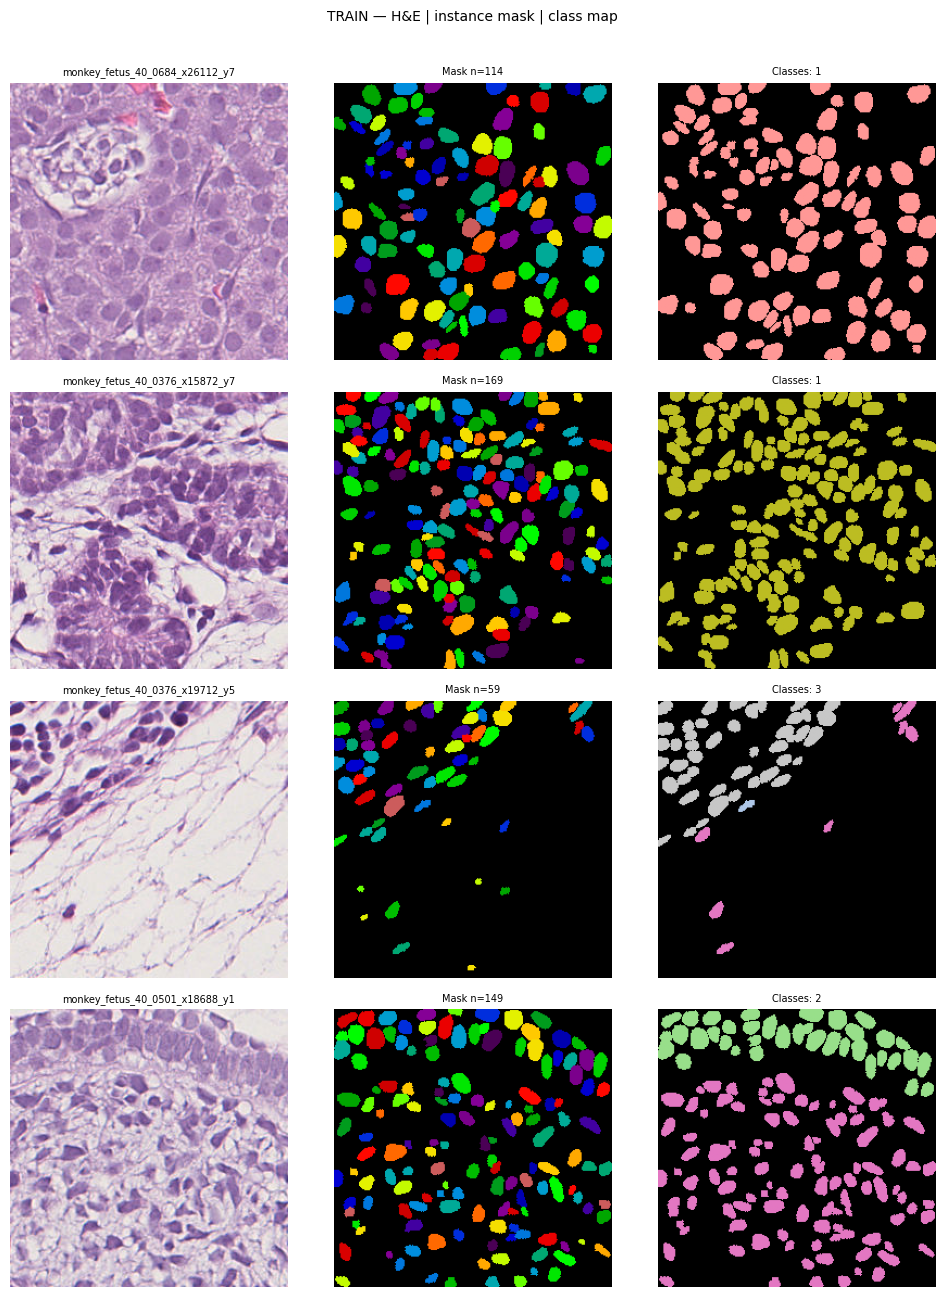

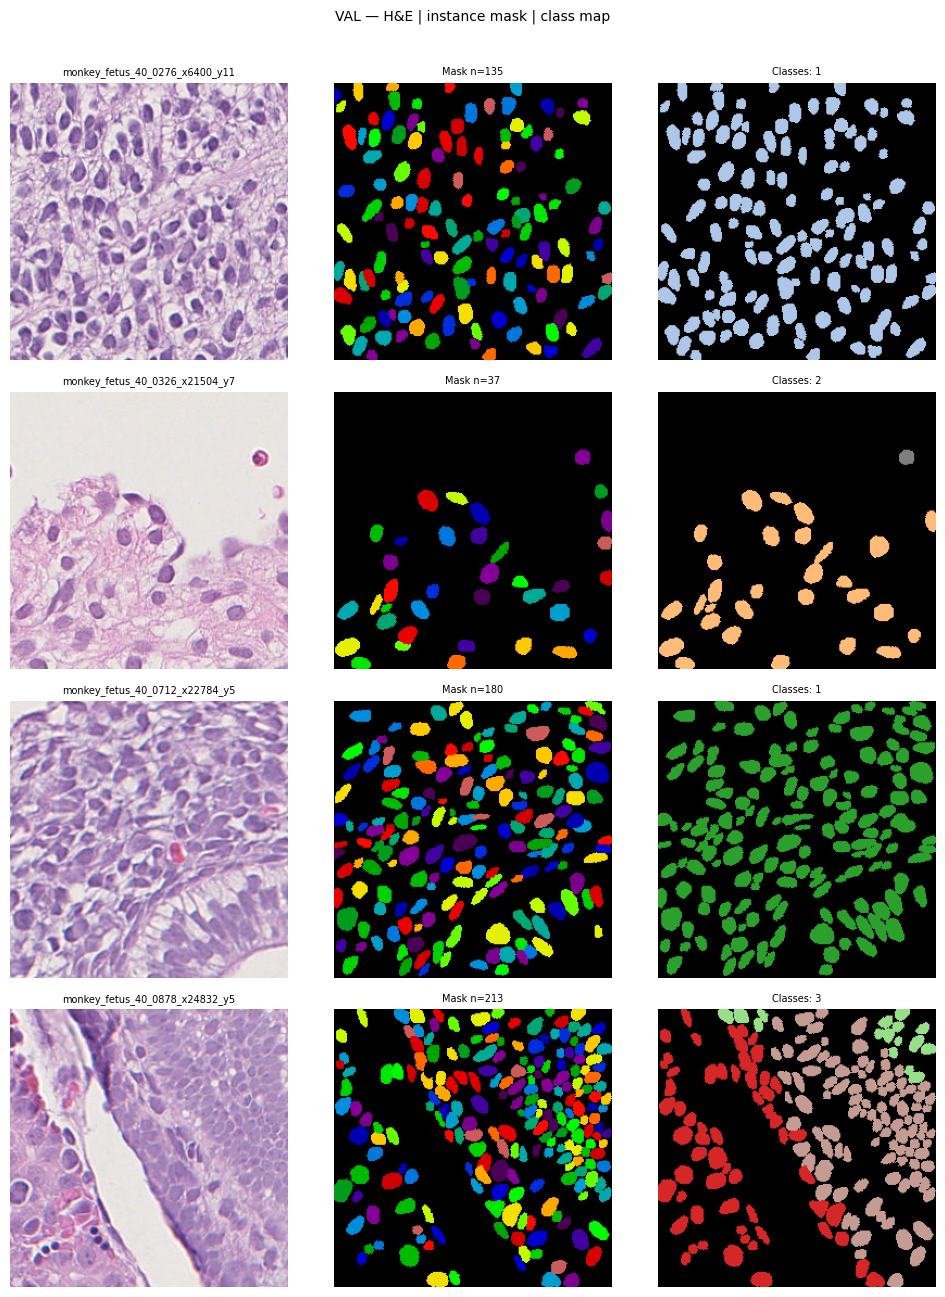

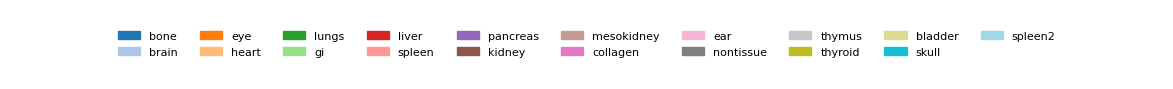

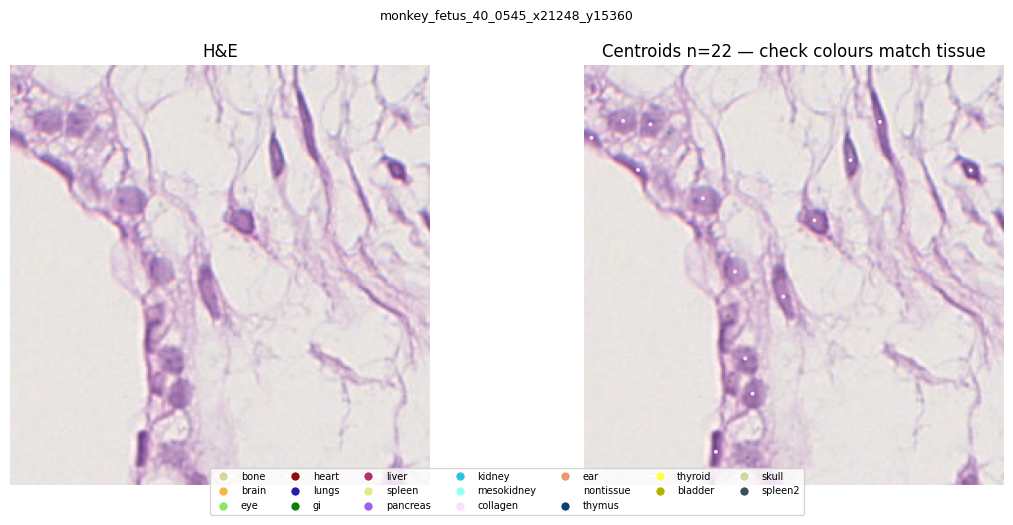

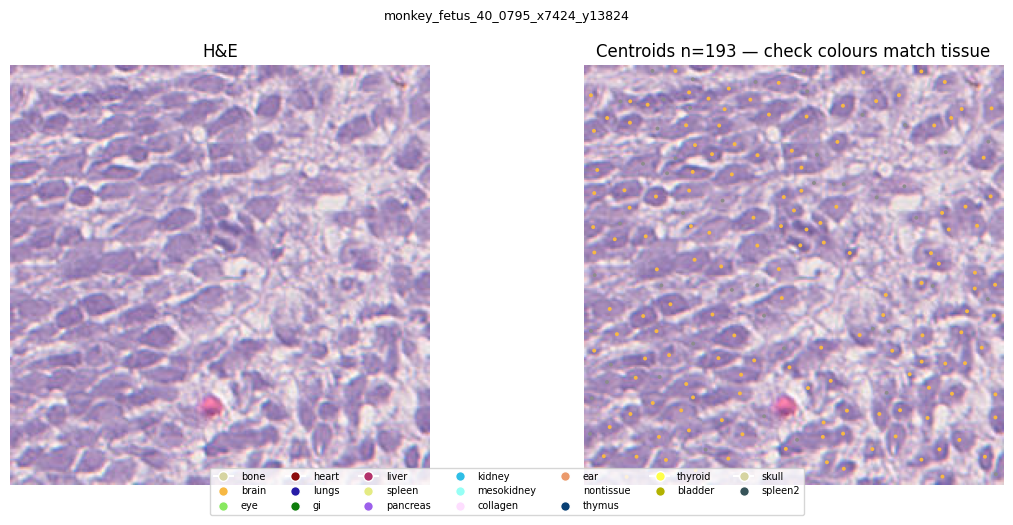

In [10]:
visualise_samples(
    train_stems,
    val_stems,
    n              = N_VISUALISE,
    train_images_dir= TRAIN_IMAGES_DIR,
    inst_labels_dir = INST_LABELS_DIR,
    class_names    = CLASS_NAMES,
    class_to_idx   = CLASS_TO_IDX,
    colors_viz     = COLORS_VIZ,
)

diagnostic_centroid_viz(
    train_stems,
    n              = N_CENTROID_DIAG,
    train_images_dir  = TRAIN_IMAGES_DIR,
    stardist_json_dir = STARDIST_JSON_DIR,
    inst_labels_dir   = INST_LABELS_DIR,
    class_names       = CLASS_NAMES,
    class_to_idx      = CLASS_TO_IDX,
    colors_viz        = COLORS_VIZ,
    out_geojson_dir   = MT_READY_DIR / "centroid_diagnostic_geojson",
)

---
## Cell 9 — Export QuPath validation GeoJSONs
Every `EXPORT_EVERY_N`-th tile gets a QuPath 0.6 GeoJSON with nuclear polygons  
coloured by tissue class.  Open a tile in QuPath and drag the `.geojson` on top.

→ `export_qupath_geojsons()` in `train_utils.py`

In [11]:
export_qupath_geojsons(
    all_stems,
    every_n           = EXPORT_EVERY_N,
    stardist_json_dir = STARDIST_JSON_DIR,
    inst_labels_dir   = INST_LABELS_DIR,
    train_images_dir  = TRAIN_IMAGES_DIR,
    out_dir           = MT_READY_DIR / "qupath_validation_geojson",
    class_names       = CLASS_NAMES,
    class_to_idx      = CLASS_TO_IDX,
    colors_viz        = COLORS_VIZ,
)

Exporting QuPath GeoJSONs: 94 tiles (every 500 of 46708)


QuPath export: 100%|██████████| 94/94 [00:15<00:00,  5.90it/s]


Done: 94 GeoJSONs | 9,439 nuclei | output: \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_256_40k_48_slides\stardist_multitask_ready\qupath_validation_geojson
  collagen           2,133  (22.6%)
  brain              1,494  (15.8%)
  unclassified       1,310  (13.9%)
  lungs                830  (8.8%)
  pancreas             527  (5.6%)
  skull                492  (5.2%)
  kidney               466  (4.9%)
  liver                444  (4.7%)
  gi                   442  (4.7%)
  thymus               362  (3.8%)
  mesokidney           266  (2.8%)
  thyroid              210  (2.2%)
  heart                 93  (1.0%)
  bone                  88  (0.9%)
  spleen                82  (0.9%)
  nontissue             77  (0.8%)
  spleen2               76  (0.8%)
  bladder               45  (0.5%)
  ear                    2  (0.0%)


94

---
## Cell 10 — Write training config YAML
Generates `config_gs40_multitask.yaml` from the parameters in Cell 2.  
Re-run this cell whenever you change a hyperparameter before launching training.

→ `build_training_config()`, `write_config()` in `train_utils.py`

In [13]:
EXPERIMENT_NAME = f"convnext_stardist_mt_gs40_v2_{datetime.now().strftime('%Y%m%d_%H%M')}"

cfg = build_training_config(
    experiment_name        = EXPERIMENT_NAME,
    train_images_dir       = TRAIN_IMAGES_DIR,
    inst_labels_dir        = INST_LABELS_DIR,
    ckpt_out               = CKPT_OUT,
    train_stems            = train_stems,
    val_stems              = val_stems,
    class_names            = CLASS_NAMES,
    # ── hyperparameters from Cell 2 ──
    epochs                 = EPOCHS,
    batch_size             = BATCH_SIZE,
    lr                     = LR,
    lr_min                 = LR_MIN,
    weight_decay           = WEIGHT_DECAY,
    freeze_backbone_epochs = FREEZE_BACKBONE_EPOCHS,
    loss_w_cls             = LOSS_W_CLS,
    loss_w_inst            = LOSS_W_INST,
    loss_w_dist            = LOSS_W_DIST,
    cls_semantic_dim       = CLS_SEMANTIC_DIM,
)

write_config(cfg, CONFIG_PATH)

Config written: C:\Users\Andre\cursor_projects\Convnext_stardist\shared_convnext_stardist_decoder\config_gs40_multitask.yaml
  experiment : convnext_stardist_mt_gs40_v2_20260410_2242
  stems      : train 38716 / val 7992
  classes    : ['bone', 'brain', 'eye', 'heart', 'lungs', 'gi', 'liver', 'spleen', 'pancreas', 'kidney', 'mesokidney', 'collagen', 'ear', 'nontissue', 'thymus', 'thyroid', 'bladder', 'skull', 'spleen2']
  epochs     : 50  batch: 4  lr: 0.0001 → 1e-06
  freeze_bb  : 5 epochs
  loss w_cls/w_inst: 2.0/0.5
  ckpt dir   : \\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_256_40k_48_slides\convnext_stardist_multitask_runs\run_fold0_FULL


---
## Cell 11 — Run training

**From terminal (recommended — live progress visible):**
```powershell
conda activate convnext_stardist_mt
cd C:\Users\Andre\cursor_projects\Convnext_stardist

# Fresh run
python -m shared_convnext_stardist_decoder.train_v2 --config shared_convnext_stardist_decoder\config_gs40_multitask.yaml

# Fine-tune from best V2 checkpoint (strict load)
python -m shared_convnext_stardist_decoder.train_v2 ^
    --config shared_convnext_stardist_decoder\config_finetune_gs40.yaml ^
    --resume "\\kittyserverdw\Andre_kit\data\students\Diogo\data\fetal\GS40\cellvit_training\dataset_256_40k_48_slides\convnext_stardist_multitask_runs\run_fold0_FULL\convnext_stardist_mt_gs40_v2_20260410_2242\best.pt"

# Warm-start from V1 (partial load: seg decoder only, cls head re-initialised)
python -m shared_convnext_stardist_decoder.train_v2 `
    --config shared_convnext_stardist_decoder\config_gs40_multitask.yaml `
    --resume <path\to\v1_best.pt> --resume_strict false
```

**What to watch in the log:**
| Column | Good sign |
|--------|-----------|
| `bce` | Decreases epoch 1→50 |
| `cls_px` | Decreases from ~1.5 toward <0.8 |
| `val cls_px` | Tracks train; large gap = overfitting → use `best.pt` |
| `dist` | Decreases toward <1.0 |

> **Fine-tuning tip:** set `RESUME_CHECKPOINT` in Cell 2, then re-run Cells 1–2 + 10–11.

In [ ]:
# Run inside notebook — or use the terminal command above instead.
# Set RESUME_CHECKPOINT and RESUME_STRICT in Cell 2 to fine-tune.

run_training(
    config_path       = CONFIG_PATH,
    repo_root         = REPO_ROOT,
    resume_checkpoint = RESUME_CHECKPOINT,
    resume_strict     = RESUME_STRICT,
)